In [3]:
import sys
import os
module_path = os.path.abspath(os.path.join(os.getcwd(), 'Lab_5_tree_search_files'))

if module_path not in sys.path:
    sys.path.append(module_path)

Початок турніру. Кількість раундів MCTS: 10
Match: T=0.25 vs T=0.5 | Wins X: 27, Wins O: 23
Match: T=0.25 vs T=1 | Wins X: 27, Wins O: 22
Match: T=0.25 vs T=2 | Wins X: 19, Wins O: 31
Match: T=0.25 vs T=4 | Wins X: 28, Wins O: 22
Match: T=0.25 vs T=8 | Wins X: 21, Wins O: 28
Match: T=0.25 vs T=16 | Wins X: 23, Wins O: 26
Match: T=0.25 vs T=32 | Wins X: 21, Wins O: 27
Match: T=0.5 vs T=1 | Wins X: 26, Wins O: 24
Match: T=0.5 vs T=2 | Wins X: 28, Wins O: 22
Match: T=0.5 vs T=4 | Wins X: 24, Wins O: 26
Match: T=0.5 vs T=8 | Wins X: 25, Wins O: 25
Match: T=0.5 vs T=16 | Wins X: 17, Wins O: 33
Match: T=0.5 vs T=32 | Wins X: 28, Wins O: 22
Match: T=1 vs T=2 | Wins X: 24, Wins O: 25
Match: T=1 vs T=4 | Wins X: 22, Wins O: 27
Match: T=1 vs T=8 | Wins X: 26, Wins O: 24
Match: T=1 vs T=16 | Wins X: 20, Wins O: 30
Match: T=1 vs T=32 | Wins X: 23, Wins O: 25
Match: T=2 vs T=4 | Wins X: 22, Wins O: 27
Match: T=2 vs T=8 | Wins X: 18, Wins O: 32
Match: T=2 vs T=16 | Wins X: 27, Wins O: 23
Match: T=2 

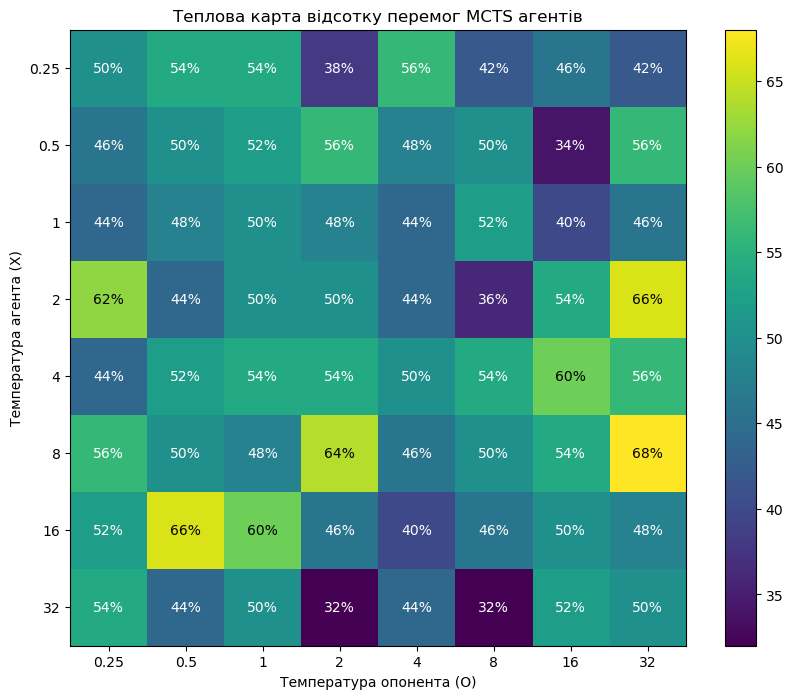

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from TicTacToeNxN import TicTacToeNxN
from agent_mcts import MCTSAgent
import tree_search_helpers

temperatures = [0.25, 0.5, 1, 2, 4, 8, 16, 32]
games_per_match = 50
num_rounds_mcts = 10

num_temps = len(temperatures)
win_matrix = np.zeros((num_temps, num_temps))
np.fill_diagonal(win_matrix, 50)

print(f"Початок турніру. Кількість раундів MCTS: {num_rounds_mcts}")

for idx, (t1, t2) in enumerate(combinations(temperatures, 2)):
    i, j = temperatures.index(t1), temperatures.index(t2)

    x_wins = 0
    o_wins = 0

    for k in range(games_per_match):
        agent_x = MCTSAgent(num_rounds=num_rounds_mcts, temperature=t1)
        agent_o = MCTSAgent(num_rounds=num_rounds_mcts, temperature=t2)

        game = TicTacToeNxN(N=4, victory_len=3, starting_player='x' if k % 2 == 0 else 'o')

        result = game.agent_vs_agent(x_player=agent_x, o_player=agent_o)

        if 'WON' in result:
            if result.lower().startswith('x'):
                x_wins += 1
            else:
                o_wins += 1

    x_win_rate = (x_wins / games_per_match) * 100
    o_win_rate = (o_wins / games_per_match) * 100

    win_matrix[i, j] = x_win_rate
    win_matrix[j, i] = o_win_rate

    print(f"Match: T={t1} vs T={t2} | Wins X: {x_wins}, Wins O: {o_wins}")

avg_win_rates = []
for i in range(num_temps):
    row_sum = np.sum(win_matrix[i, :]) - win_matrix[i, i]
    avg = row_sum / (num_temps - 1)
    avg_win_rates.append(avg)

best_idx = np.argmax(avg_win_rates)
print(f"Найкраща температура: {temperatures[best_idx]} (Середній Win Rate: {avg_win_rates[best_idx]:.2f}%)")

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(win_matrix, cmap='viridis')

ax.set_xticks(np.arange(num_temps))
ax.set_yticks(np.arange(num_temps))
ax.set_xticklabels(temperatures)
ax.set_yticklabels(temperatures)
ax.set_xlabel("Температура опонента (O)")
ax.set_ylabel("Температура агента (X)")

for i in range(num_temps):
    for j in range(num_temps):
        text = ax.text(j, i, f"{win_matrix[i, j]:.0f}%",
                       ha="center", va="center", color="w" if win_matrix[i, j] < 60 else "black")

ax.set_title("Теплова карта відсотку перемог MCTS агентів")
fig.colorbar(im, ax=ax)
plt.show()